# SC Research Notebook

Layer 1 (INE crude) data pulls for the China aromatics value chain.

**Scripts:** `code/sc_term_structure.py` · `code/sc_basis.py` · `code/china_crude_supply_demand.py` · `code/fetch_refinery_utilization.py` · `code/sc_warehouse_receipts.py` · `code/px_spot.py` · `code/ta_eg_basis.py`  
**Wind (Dubai daily):** `code/fetch_wind.py` — requires Wind terminal + WindPy  
**Data docs:** `data/sc_data_sources.md`

Run all cells to refresh CSV/JSON outputs in `data/`.

In [5]:
import json
import sys
from pathlib import Path

import pandas as pd

ROOT = Path.cwd()
CODE = ROOT / "code"
DATA = ROOT / "data"
sys.path.insert(0, str(CODE))

print(f"Project root: {ROOT}")
print(f"Data dir: {DATA}")

Project root: /Users/tyau/Documents/job_app/applications/2026-06-clocktower-investment-analyst/Clocktower coding and financial knowledge test materials/Presentation - China Chemical Industry Value Chain
Data dir: /Users/tyau/Documents/job_app/applications/2026-06-clocktower-investment-analyst/Clocktower coding and financial knowledge test materials/Presentation - China Chemical Industry Value Chain/data


In [6]:
# 1) SC term structure snapshot (front vs ~6M)
from sc_term_structure import build_term_structure_snapshot

curve, term_summary = build_term_structure_snapshot()
display(curve.head(10))
print(json.dumps(term_summary, indent=2))

,symbol,contract_month,close,settle,volume,open_interest,trade_date
0,SC2607,2026-07,503.0,505.1,437,1512,2026-06-22
1,SC2608,2026-08,507.2,510.5,24743,50948,2026-06-22
2,SC2609,2026-09,510.9,513.3,10464,23047,2026-06-22
3,SC2610,2026-10,511.5,512.9,1731,6764,2026-06-22
4,SC2611,2026-11,511.9,512.9,191,1639,2026-06-22
5,SC2612,2026-12,512.0,512.5,716,7193,2026-06-22
6,SC2701,2027-01,509.8,512.7,45,445,2026-06-22
7,SC2702,2027-02,508.8,508.0,17,336,2026-06-22
8,SC2703,2027-03,506.5,507.6,37,334,2026-06-22
9,SC2704,2027-04,503.0,503.1,3,8,2026-06-22


{
  "front_symbol": "SC2608",
  "front_month": "2026-08",
  "front_settle_cny_bbl": 510.5,
  "front_open_interest": 50948,
  "six_m_symbol": "SC2702",
  "six_m_month": "2027-02",
  "six_m_settle_cny_bbl": 508.0,
  "months_apart": 6,
  "spread_cny_bbl": -2.5,
  "spread_pct_of_front": -0.4897159647404506,
  "annualized_roll_yield_pct": -0.9794319294809012,
  "term_structure": "backwardation",
  "trade_date": "2026-06-22",
  "as_of_utc": "2026-06-23T01:58:05.953247+00:00",
  "source": "akshare.get_futures_daily(market='INE')",
  "note": "Contango (positive front\u21926M spread) implies storage/carry incentive at INE bonded delivery sites; backwardation implies tight near-term supply."
}


In [7]:
# 2) SC vs Brent/Dubai basis (Dubai = Wind EDB daily when terminal available)
from sc_basis import build_basis_panel, summarize_basis

basis_panel, dubai_source = build_basis_panel()
basis_summary = summarize_basis(basis_panel, dubai_source=dubai_source)
display(basis_panel.tail())
print(f"Dubai source: {dubai_source}")
print(json.dumps(basis_summary, indent=2)) 

,date,sc_cny_bbl,brent_usd_bbl,dubai_usd_bbl,cny_usd,sc_usd_bbl,basis_sc_minus_brent_usd,basis_sc_minus_dubai_usd,basis_sc_minus_brent_pct
751,2026-06-15,530.8,83.36,102.282308,6.7570,78.555572,-4.804428,-23.726736,-5.763469
752,2026-06-16,527.5,79.32,102.282308,6.7562,78.076433,-1.243567,-24.205874,-1.567784
753,2026-06-17,510.2,78.39,102.282308,6.7577,75.499060,-2.890940,-26.783247,-3.687893
754,2026-06-18,508.5,78.94,102.282308,6.7686,75.126319,-3.813681,-27.155989,-4.831114
755,2026-06-22,507.2,77.80,102.282308,6.7686,74.934255,-2.865745,-27.348052,-3.683477


{
  "as_of_utc": "2026-06-23T01:58:14.707783+00:00",
  "latest_date": "2026-06-22",
  "sc_cny_bbl": 507.2,
  "sc_usd_bbl": 74.93,
  "brent_usd_bbl": 77.8,
  "dubai_usd_bbl": 102.28,
  "cny_usd": 6.7686,
  "basis_sc_minus_brent_usd": -2.87,
  "basis_sc_minus_dubai_usd": -27.35,
  "basis_sc_minus_brent_pct": -3.68,
  "basis_zscore_3y": -1.08,
  "basis_mean_3y_usd": 0.75,
  "basis_std_3y_usd": 3.34,
  "lookback_days": 756,
  "sources": {
    "sc": "akshare.futures_main_sina(symbol='SC0')",
    "brent": "akshare.futures_foreign_hist(symbol='OIL') \u2014 ICE Brent daily proxy",
    "dubai": "FRED POILDUBUSDM (monthly Dubai spot, ffill)",
    "fx": "FRED DEXCHUS"
  },
  "interpretation": "Negative basis = SC below Brent/Dubai in USD (cheaper China landed cost); positive = premium vs offshore benchmarks after FX conversion."
}


In [8]:
# 3) China crude imports vs refining + CDU utilization
from china_crude_supply_demand import build_supply_demand_panel, summarize
from fetch_refinery_utilization import load_refinery_utilization, summarize_refinery_utilization

supply_panel = build_supply_demand_panel()
util_df = load_refinery_utilization()
util_summary = summarize_refinery_utilization(util_df)
supply_summary = summarize(supply_panel, util_summary)
display(supply_panel.tail())
display(util_df)
print(json.dumps(supply_summary, indent=2))

,period,crude_imports_tbpd,crude_production_tbpd,total_petroleum_consumption_tbpd,refinery_runs_tbpd,crude_supply_to_refineries_tbpd,import_dependence_pct,imports_yoy_pct,refinery_runs_yoy_pct,import_minus_refinery_growth_pp
5,2020-01-01,10855.068493,3898.630137,13000.0,13000.0,14753.698630,73.575235,6.573957,1.562500,5.011457
6,2021-01-01,10320.547945,3994.520548,13500.0,13500.0,14315.068493,72.095694,-4.924156,3.846154,-8.770310
7,2022-01-01,10470.410959,4087.671233,14000.0,14000.0,14558.082192,71.921637,1.452084,3.703704,-2.251620
8,2023-01-01,11300.000000,4200.000000,14800.0,14800.0,15500.000000,72.903226,7.923176,5.714286,2.208890
9,2024-01-01,11100.000000,4324.684932,14200.0,14200.0,15424.684932,71.962572,-1.769912,-4.054054,2.284143


,week_end,util_all_pct,util_major_pct,util_independent_pct,util_megaproject_pct,source,notes
0,2026-02-26,73.38,82.17,60.63,98.99,OilChem (隆众资讯),Pre Middle East conflict baseline; week of 202...
1,2026-06-11,58.43,67.36,45.47,61.35,OilChem (隆众资讯),Weekly CDU utilization; week ending 2026-06-11
2,2026-06-18,57.54,67.23,43.47,59.23,OilChem (隆众资讯),Weekly CDU utilization; week ending 2026-06-18...


{
  "as_of_utc": "2026-06-23T01:58:14.733994+00:00",
  "latest_year": 2024,
  "crude_imports_tbpd": 11100.0,
  "crude_production_tbpd": 4324.7,
  "refinery_runs_tbpd": 14200.0,
  "import_dependence_pct": 72.0,
  "imports_yoy_pct": -1.77,
  "refinery_runs_yoy_pct": -4.05,
  "prior_year": 2023,
  "capacity_cycle_phase_annual": "imports declining slower than runs (inventory/build risk)",
  "refinery_utilization": {
    "as_of_utc": "2026-06-23T01:58:14.733160+00:00",
    "latest_week_end": "2026-06-18",
    "util_all_pct": 57.54,
    "util_major_pct": 67.23,
    "util_independent_pct": 43.47,
    "util_megaproject_pct": 59.23,
    "wow_change_all_pp": -0.89,
    "vs_pre_conflict_baseline_pp": -15.84,
    "pre_conflict_baseline_week": "2026-02-26",
    "pre_conflict_baseline_all_pct": 73.38,
    "cycle_phase": "sharp run-cut phase (utilization well below pre-shock baseline)",
    "source": "OilChem (\u9686\u4f17\u8d44\u8baf)",
    "source_url": "https://www.oilchem.net/26-0618-16-ec4c64f37

In [9]:
# Persist all outputs (same as running CLI scripts)
import sc_term_structure
import sc_basis
import china_crude_supply_demand
import fetch_refinery_utilization
import sc_warehouse_receipts

sc_term_structure.main()
sc_basis.main()
china_crude_supply_demand.main()
fetch_refinery_utilization.main()
sc_warehouse_receipts.main()

Wrote /Users/tyau/Documents/job_app/applications/2026-06-clocktower-investment-analyst/Clocktower coding and financial knowledge test materials/Presentation - China Chemical Industry Value Chain/data/sc_term_structure_curve.csv (20 contracts)
Wrote /Users/tyau/Documents/job_app/applications/2026-06-clocktower-investment-analyst/Clocktower coding and financial knowledge test materials/Presentation - China Chemical Industry Value Chain/data/sc_term_structure_summary.json

Term structure snapshot:
  trade_date: 2026-06-22
  front_symbol: SC2608
  six_m_symbol: SC2702
  spread_cny_bbl: -2.5
  spread_pct_of_front: -0.4897159647404506
  annualized_roll_yield_pct: -0.9794319294809012
  term_structure: backwardation
Wrote /Users/tyau/Documents/job_app/applications/2026-06-clocktower-investment-analyst/Clocktower coding and financial knowledge test materials/Presentation - China Chemical Industry Value Chain/data/sc_basis_daily.csv (756 rows)
Wrote /Users/tyau/Documents/job_app/applications/202

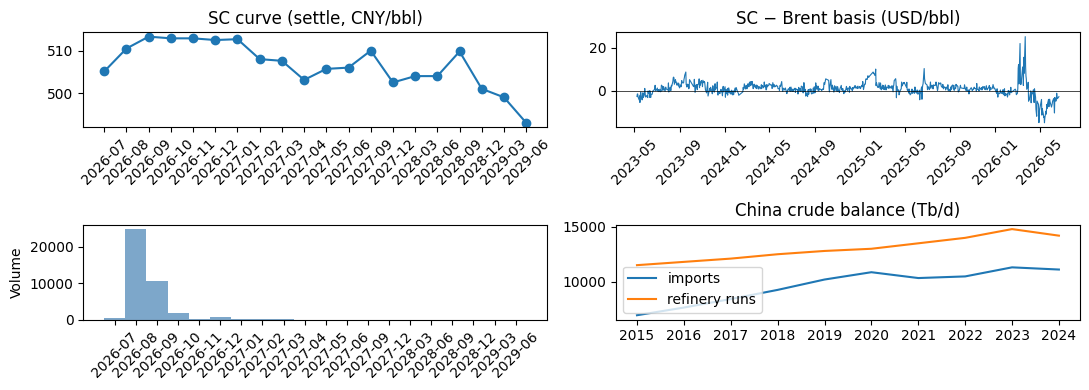

In [10]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

fig, axes = plt.subplots(2, 2, figsize=(11, 4))

# plot the term structure
c = curve.sort_values("contract_month")
axes[0,0].plot(c["contract_month"], c["settle"], marker="o")
axes[0,0].set_title("SC curve (settle, CNY/bbl)")
axes[0,0].tick_params(axis="x", rotation=45)

# plot the volume
axes[1,0].bar(c["contract_month"], c["volume"], width=1, color="steelblue", alpha=0.7)
axes[1,0].set_ylabel("Volume")
axes[1,0].tick_params(axis="x", rotation=45)

# plot the basis
bp = basis_panel.set_index("date")
axes[0,1].plot(bp.index, bp["basis_sc_minus_brent_usd"], lw=0.8)
axes[0,1].axhline(0, color="k", lw=0.5)
axes[0,1].set_title("SC − Brent basis (USD/bbl)")
axes[0,1].tick_params(axis="x", rotation=45)

#plot the crude balance
sp = supply_panel.dropna(subset=["crude_imports_tbpd", "refinery_runs_tbpd"])
axes[1,1].plot(sp["period"], sp["crude_imports_tbpd"], label="imports")
axes[1,1].plot(sp["period"], sp["refinery_runs_tbpd"], label="refinery runs")
axes[1,1].set_title("China crude balance (Tb/d)")
axes[1,1].legend()

plt.tight_layout()
plt.show()

In [11]:
# 4) INE SC warehouse receipts + fitted models
import numpy as np
from sc_warehouse_receipts import build_receipt_panel

receipt_df, receipt_summary = build_receipt_panel()
display(receipt_df.tail(10))
print(json.dumps(receipt_summary, indent=2))

,var,receipt,receipt_chg,date
492,SC,2961000,0,2026-06-09
493,SC,2961000,0,2026-06-10
494,SC,2961000,0,2026-06-11
495,SC,2961000,0,2026-06-12
496,SC,2961000,0,2026-06-15
497,SC,2961000,0,2026-06-16
498,SC,2961000,0,2026-06-17
499,SC,2961000,0,2026-06-18
500,SC,2961000,0,2026-06-22
501,SC,2961000,0,2026-06-23


{
  "as_of_utc": "2026-06-23T12:19:07.133901+00:00",
  "latest_date": "2026-06-23",
  "receipt_bbl": 2961000,
  "receipt_chg_day": 0,
  "receipt_zscore_full_sample": -1.18,
  "receipt_mean_bbl": 5331440.0,
  "receipt_std_bbl": 2015822.0,
  "receipt_min_bbl": 2557000,
  "receipt_max_bbl": 10653000,
  "change_20d_bbl": -550000,
  "n_obs": 502,
  "start_date": "2024-05-28",
  "source": "akshare get_shfe_receipt_2/3 (SC via INE/SHFE warehouse API)",
  "models": {
    "linear_trend": {
      "model": "OLS linear trend",
      "n_obs": 502,
      "intercept_bbl": 7935089.0,
      "slope_bbl_per_day": -10393.8,
      "slope_bbl_per_year": -2619240.0,
      "r_squared": 0.5594,
      "aic": 15590.7
    },
    "ar1_level": {
      "model": "AR(1) on level",
      "n_obs": 502,
      "const": 5331440.0,
      "ar1_coef": 0.9787,
      "aic": 14432.3,
      "bic": 14444.9,
      "half_life_days": 32.2
    }
  },
  "interpretation": "Rising receipts at INE delivery sites = storage build / delivera

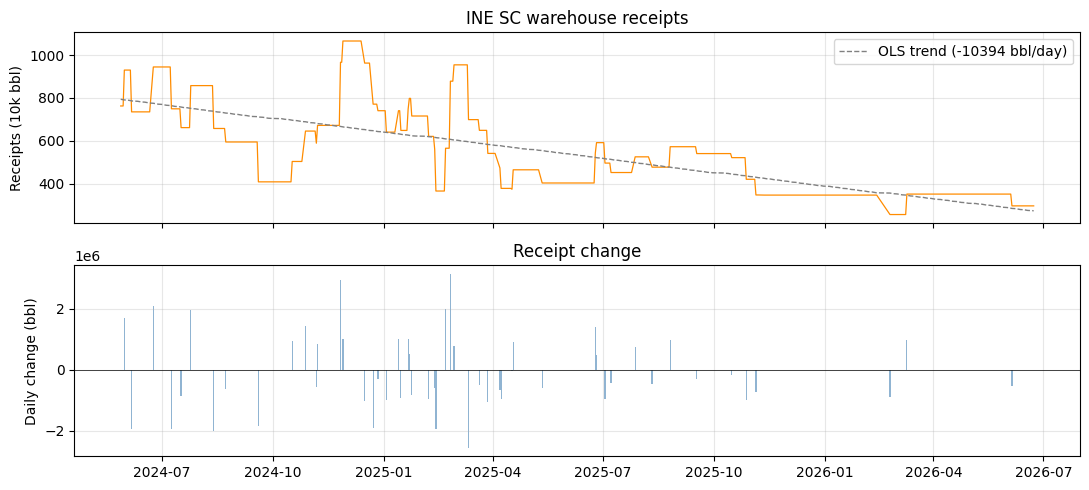

In [12]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 1, figsize=(11, 5), sharex=True)

ax0 = axes[0]
ax0.plot(receipt_df["date"], receipt_df["receipt"] / 1e4, lw=0.9, color="darkorange")
ax0.set_ylabel("Receipts (10k bbl)")
ax0.set_title("INE SC warehouse receipts")
ax0.grid(alpha=0.3)

models = receipt_summary["models"]
t = np.arange(len(receipt_df))
intercept = models["linear_trend"]["intercept_bbl"]
slope = models["linear_trend"]["slope_bbl_per_day"]
ax0.plot(
    receipt_df["date"],
    (intercept + slope * t) / 1e4,
    "--",
    color="gray",
    lw=1,
    label=f"OLS trend ({slope:.0f} bbl/day)",
)
ax0.legend()

ax1 = axes[1]
ax1.bar(receipt_df["date"], receipt_df["receipt_chg"], width=1, color="steelblue", alpha=0.6)
ax1.axhline(0, color="k", lw=0.5)
ax1.set_ylabel("Daily change (bbl)")
ax1.set_title("Receipt change")
ax1.grid(alpha=0.3)

plt.tight_layout()
plt.show()